# Matplotlib Histograms

In [1]:
import ast
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset

# Load data
dataset = load_dataset("lukebarousse/data_jobs")
df = dataset["train"].to_pandas()

# Data cleanup
df["job_posted_date"] = pd.to_datetime(df["job_posted_date"])
df["job_skills"] = df["job_skills"].apply(lambda skill: ast.literal_eval(skill)
                                          if pd.notna(skill) else skill)

c:\Users\PC\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Only get data analyst jobs in the US
df_DA_US = df[(df["job_title_short"] == "Data Analyst") & (df["job_country"] == "United States")].copy()

In [3]:
df_DA_US["salary_year_avg"]

36       NaN
68       NaN
73       NaN
79       NaN
93       NaN
          ..
785603   NaN
785626   NaN
785685   NaN
785703   NaN
785705   NaN
Name: salary_year_avg, Length: 67816, dtype: float64

<Axes: ylabel='Frequency'>

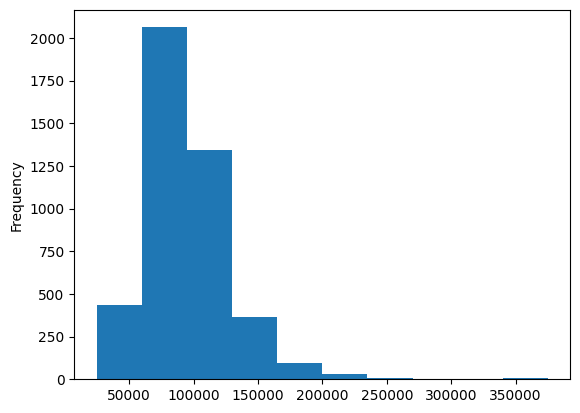

In [4]:
df_DA_US["salary_year_avg"].plot(kind="hist")

<Axes: ylabel='Frequency'>

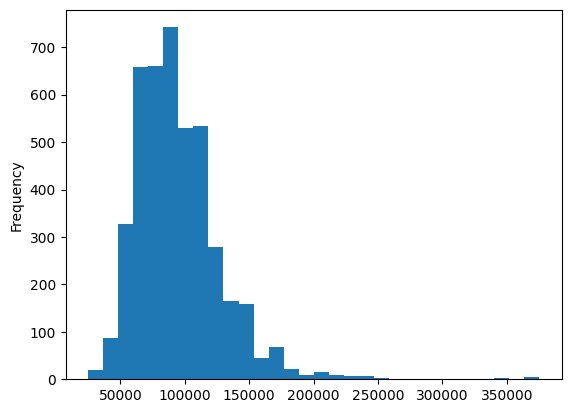

In [5]:
df_DA_US["salary_year_avg"].plot(kind="hist", bins=30)

<Axes: ylabel='Frequency'>

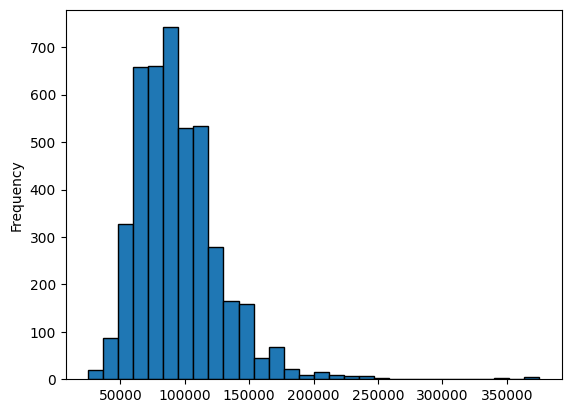

In [6]:
df_DA_US["salary_year_avg"].plot(kind="hist", bins=30, edgecolor="black")

(0.0, 250000.0)

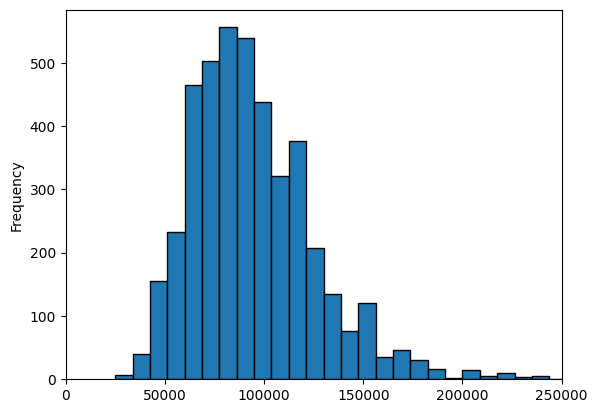

In [8]:
df_DA_US["salary_year_avg"].plot(kind="hist", bins=40, edgecolor="black")
plt.xlim(0, 250000)

(0.0, 250000.0)

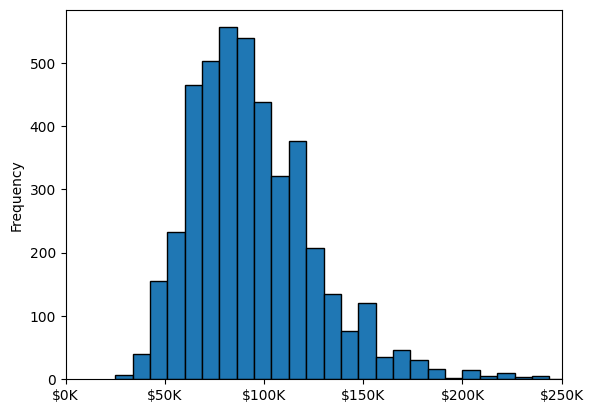

In [12]:
fig, ax = plt.subplots()

df_DA_US["salary_year_avg"].plot(kind="hist", bins=40, edgecolor="black", ax=ax)

def format_salary(x, pos):
    return f"${int(x / 1000)}K"

ax.xaxis.set_major_formatter(plt.FuncFormatter(format_salary))
plt.xlim(0, 250000)

(0.0, 250000.0)

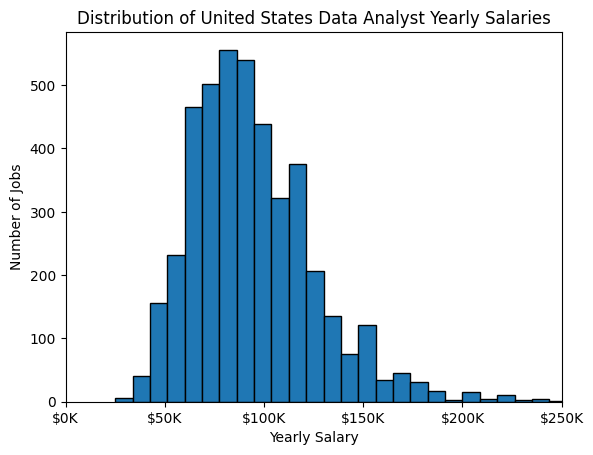

In [14]:
# Using lambda
fig, ax = plt.subplots()

df_DA_US["salary_year_avg"].plot(kind="hist", bins=40, edgecolor="black", ax=ax)

ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${int(x / 1000)}K"))
plt.title("Distribution of United States Data Analyst Yearly Salaries")
plt.xlabel("Yearly Salary")
plt.ylabel("Number of Jobs")
plt.xlim(0, 250000)